# Vision Model



## Pre-trained VGG-11 for Image Classification

First, we will be using PyTorch for this task,. It is a popular machine learning framework. Should be able to install it according to the official instructions on [pytorch.org](https://pytorch.org/).

* Initializing and importing the VGG-11 model using PyTorch. Using it for classifying at least 20 CIFAR10 Images, without training it from scratch.

Training for 1 epoch or a few iterations is totally fine, especially if you run it on cpu. Speed depends on your hardware. You can use Google Colab if you don't have a GPU available, to have a bit more compute.

Predicted ImageNet class indices for 20 CIFAR-10 images:
[502 510 860 252 675 675 268 158 675 675 795 158 278 675 392  80 152 103
 675 675]


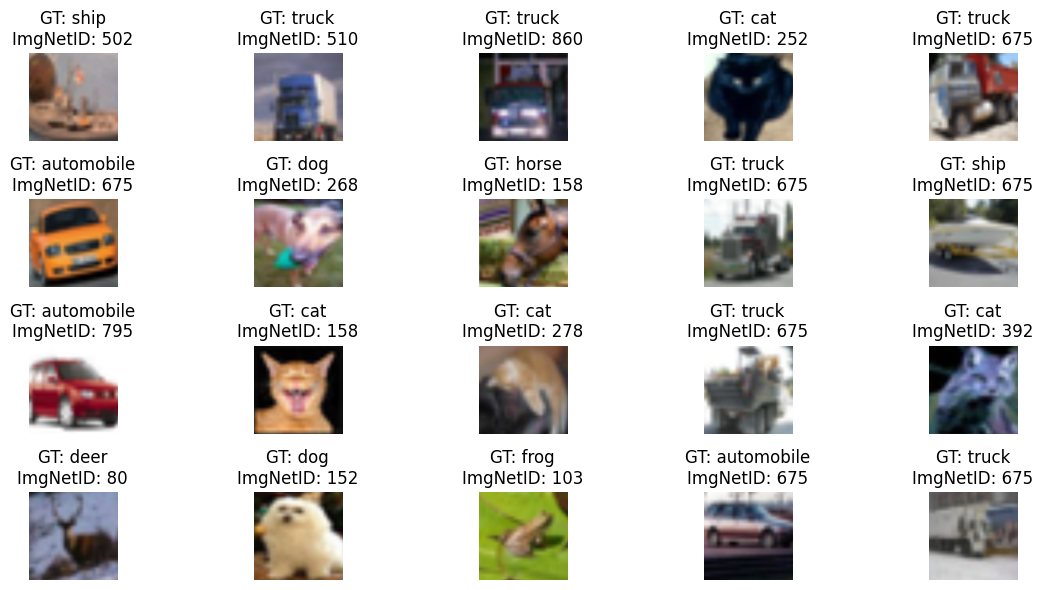

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use weights API when available
try:
    weights = models.VGG11_BN_Weights.DEFAULT
    vgg11 = models.vgg11_bn(weights=weights)
    preprocess = weights.transforms()
except Exception:
    vgg11 = models.vgg11_bn(pretrained=True)
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

vgg11 = vgg11.to(device)
vgg11.eval()

# CIFAR-10 classes (for display)
cifar10_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# Load CIFAR-10 (no training needed)
test_set = CIFAR10(root="./data", train=False, download=True, transform=preprocess)
test_loader = DataLoader(test_set, batch_size=20, shuffle=True, num_workers=2)

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = vgg11(images)            # ImageNet logits (1000 classes)
    preds = logits.argmax(dim=1)      # Still 1000-class IDs (not CIFAR-10)

print("Predicted ImageNet class indices for 20 CIFAR-10 images:")
print(preds.cpu().numpy())

# Show the 20 images with their true CIFAR-10 labels (predictions are ImageNet IDs here)
# Need unnormalize for visualization (only if using weights transforms)
def unnormalize(img):
    # If weights.transforms() used, these are ImageNet stats
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(3,1,1)
    return (img * std + mean).clamp(0, 1)

imgs_vis = images.detach().clone()
try:
    imgs_vis = unnormalize(imgs_vis)
except Exception:
    pass

imgs_vis = imgs_vis.cpu().permute(0, 2, 3, 1).numpy()

plt.figure(figsize=(12, 6))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(imgs_vis[i])
    plt.title(f"GT: {cifar10_classes[labels[i].item()]}\nImgNetID: {preds[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## UNet

Now, we want to train another Vision model from scratch again. Moving towards another Vision Task: Image Segmentation.

* Implementing a super small UNet using convolutional layers. The model should be around the parameter count 1-2 million.
* Make sure to use Skip Connections.
* Train your model on the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) for image segmentation.
* Display some segmentation results on test images.

Feel free to use a subset of the dataset, if you are restricted with memory and/or compute. You will find it in ```./data/pet/```.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class SmallUNet(nn.Module):
    """
    Very small U-Net for image segmentation
    Input: 128x128x3, Output: 128x128x1 (binary mask)
    """
    def __init__(self, in_channels=3, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)        # 128
        self.pool1 = nn.MaxPool2d(2)                     # 64
        self.enc2 = DoubleConv(base, base*2)             # 64
        self.pool2 = nn.MaxPool2d(2)                     # 32
        self.enc3 = DoubleConv(base*2, base*4)           # 32
        self.pool3 = nn.MaxPool2d(2)                     # 16

        self.bottleneck = DoubleConv(base*4, base*8)     # 16

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)  # 32
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)  # 64
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)    # 128
        self.dec1 = DoubleConv(base*2, base)

        self.out = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))
        xb = self.bottleneck(self.pool3(x3))

        x = self.up3(xb)
        x = torch.cat([x, x3], dim=1)   # skip connection
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)   # skip connection
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)   # skip connection
        x = self.dec1(x)

        return self.out(x)


In [ ]:
# # EXAMPLE PET SUBSET USAGE

# class PetsNPZDataset(Dataset):
#     """Custom Dataset to load from saved NPZ files"""

#     def __init__(self, npz_path, transform=None, target_transform=None):
#         self.data = np.load(npz_path)
#         self.images = self.data['images']
#         self.masks = self.data['masks']
#         self.transform = transform
#         self.target_transform = target_transform

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         image = self.images[idx]
#         mask = self.masks[idx]

#         # Convert to PIL or torch tensor if transforms are provided
#         if self.transform:
#             image = torch.from_numpy(image).float() / 255.0
#             image = image.permute(2, 0, 1)  # (H, W, C) -> (C, H, W)

#         if self.target_transform:
#             mask = torch.from_numpy(mask).unsqueeze(0).float()

#         return image, mask

# # Load the saved dataset
# train_dataset = PetsNPZDataset('./data/pet/pets_train_20percent.npz', transform=True, target_transform=True)
# test_dataset = PetsNPZDataset('./data/pet/pets_test_20percent.npz', transform=True, target_transform=True)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# print(f"Dataset loaded: {len(train_dataset)} train, {len(test_dataset)} test samples")


Trainable parameters: 1927009
Epoch 1/10 | train loss 0.4466 | test loss 0.3919
Epoch 2/10 | train loss 0.3508 | test loss 0.3382
Epoch 3/10 | train loss 0.3100 | test loss 0.3315
Epoch 4/10 | train loss 0.2850 | test loss 0.2529
Epoch 5/10 | train loss 0.2608 | test loss 0.2368
Epoch 6/10 | train loss 0.2462 | test loss 0.2474
Epoch 7/10 | train loss 0.2321 | test loss 0.2250
Epoch 8/10 | train loss 0.2210 | test loss 0.2232
Epoch 9/10 | train loss 0.2053 | test loss 0.2129
Epoch 10/10 | train loss 0.1940 | test loss 0.2301


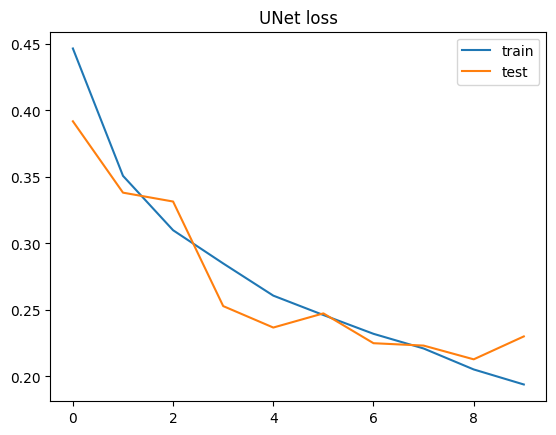

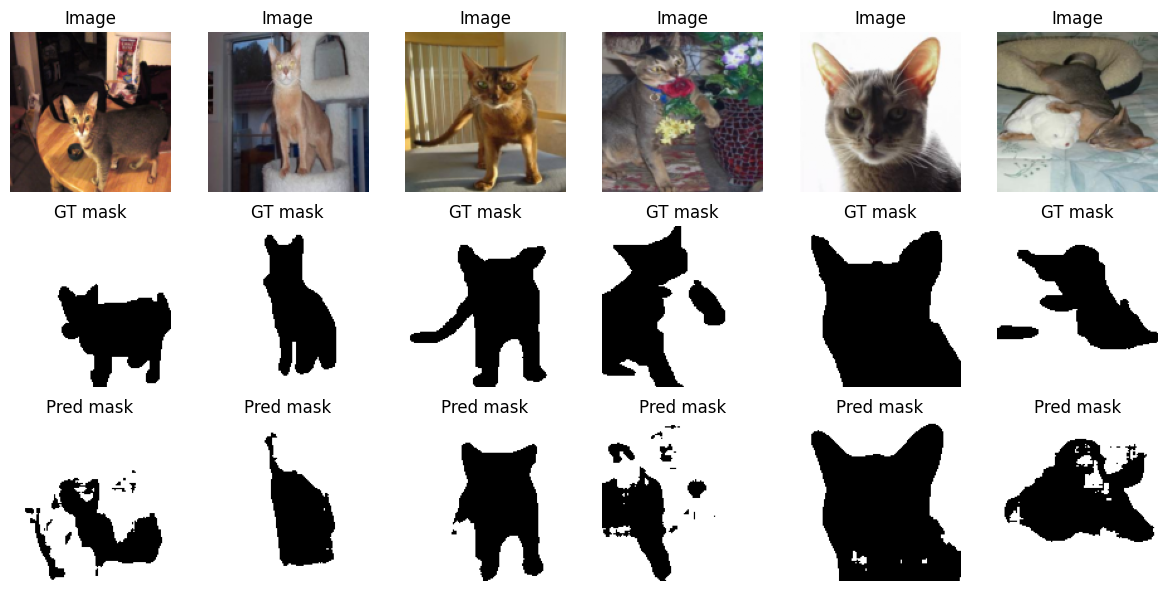

In [ ]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pet dataset returns (image, target) where target is a segmentation mask for "target_types='segmentation'"
img_size = 128

img_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

mask_transform = transforms.Compose([
    transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),  # keeps integer labels
])

train_ds = OxfordIIITPet(root="./data/pet", split="trainval", target_types="segmentation",
                         download=True, transform=img_transform, target_transform=mask_transform)
test_ds  = OxfordIIITPet(root="./data/pet", split="test", target_types="segmentation",
                         download=True, transform=img_transform, target_transform=mask_transform)

# Optional subset if compute-limited
# train_ds = torch.utils.data.Subset(train_ds, range(0, 800))
# test_ds  = torch.utils.data.Subset(test_ds, range(0, 200))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

model = SmallUNet(in_channels=3, out_channels=1, base=32).to(device)

# Parameter count check (target 1–2M)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", params)

# Pet masks: typically {1,2,3} (background, pet, border). Convert to binary "pet vs background"
def masks_to_binary(m):
    # m: (B,1,H,W) uint8
    # treat class 2 (pet) as 1, everything else 0
    return (m == 2).float()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch():
    model.train()
    total_loss = 0.0
    for x, m in train_loader:
        x = x.to(device)
        m = m.to(device)
        y = masks_to_binary(m)  # (B,1,H,W)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def eval_one_epoch():
    model.eval()
    total_loss = 0.0
    for x, m in test_loader:
        x = x.to(device)
        m = m.to(device)
        y = masks_to_binary(m)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
    return total_loss / len(test_loader.dataset)

# Train a few epochs (increase if you have time/GPU)
epochs = 10
train_losses, test_losses = [], []
for e in range(1, epochs + 1):
    tr = train_one_epoch()
    te = eval_one_epoch()
    train_losses.append(tr); test_losses.append(te)
    print(f"Epoch {e}/{epochs} | train loss {tr:.4f} | test loss {te:.4f}")

plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.title("UNet loss")
plt.legend()
plt.show()

# Display segmentation results on a few test images
@torch.no_grad()
def show_preds(n=6):
    model.eval()
    x, m = next(iter(test_loader))
    x = x.to(device)
    m = m.to(device)

    logits = model(x)
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5).float()

    x = x.cpu().permute(0,2,3,1).numpy()
    gt = masks_to_binary(m).cpu().squeeze(1).numpy()
    pr = pred.cpu().squeeze(1).numpy()

    n = min(n, x.shape[0])
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(3, n, i+1)
        plt.imshow(x[i]); plt.axis("off"); plt.title("Image")
        plt.subplot(3, n, n+i+1)
        plt.imshow(gt[i], cmap="gray"); plt.axis("off"); plt.title("GT mask")
        plt.subplot(3, n, 2*n+i+1)
        plt.imshow(pr[i], cmap="gray"); plt.axis("off"); plt.title("Pred mask")
    plt.tight_layout()
    plt.show()

show_preds(n=6)
